In [1]:
try:
    import firedrake
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/firedrake-install-release-real.sh" -O "/tmp/firedrake-install.sh" && bash "/tmp/firedrake-install.sh"
    import firedrake

firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [1]:
from firedrake import *
import matplotlib.pyplot as plt
import numpy as np
from math import ceil

from firedrake.petsc import PETSc
import petsc4py

from time import perf_counter

firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance


---
---
# Exercise 1
## Solve unsteady Navier-Stokes problem with semi-implicit treatment of the advection term.

\begin{equation*}
\begin{cases}
\frac{\partial\boldsymbol{u}}{\partial t} + (\boldsymbol{u}\cdot\nabla)\boldsymbol{u} - \frac{1}{\rm Re}\Delta \boldsymbol{u} + \nabla  p  = \boldsymbol{f} & {\rm in} \ \Omega=(0,1)^2
\quad\forall t\in(0,1), \\
{\rm div}\,\boldsymbol{u} = 0 & {\rm in} \ \Omega
\quad\forall t\in(0,1), \\
\boldsymbol{u} = \boldsymbol{u}_\text{ex} & {\rm on} \ \partial\Omega
\quad\forall t\in(0,1), \\
\boldsymbol{u} = \boldsymbol{0} & {\rm in} \ \Omega,
\quad{\rm for} \ t=0.
\end{cases}
\end{equation*}

In [13]:
def ex1_assemble_Euler(V, Q, Re, n, dt, t, u_old, u_ex, p_ex, f, create_pc_form=None, get_nsp=False):
    # Solve monolithic problem.
    W = MixedFunctionSpace([V, Q])

    # Trial and test functions.
    u, p = TrialFunctions(W)
    v, q = TestFunctions(W)

    # # Variational form and functional - explicit Euler
    # a = Constant(1.0/dt) * inner(u, v) * dx \
    #     - div(v) * p * dx \
    #     + div(u) * q * dx
    # L = Constant(1.0/dt) * inner(u_old, v) * dx \
    #     - Constant(1.0/Re) * inner(grad(u), grad(v)) * dx \
    #     - inner(dot(grad(u_old), u_old), v) * dx \
    #     + inner(f, v) * dx
    # # Variational form and functional - semi-implicit Euler with explicit advection
    # a = Constant(1.0/dt) * inner(u, v) * dx \
    #     + Constant(1.0/Re) * inner(grad(u), grad(v)) * dx \
    #     - div(v) * p * dx \
    #     + div(u) * q * dx
    # L = Constant(1.0/dt) * inner(u_old, v) * dx \
    #     - inner(dot(grad(u_old), u_old), v) * dx \
    #     + inner(f, v) * dx
    # Variational form and functional - implicit Euler with semi-implicit advection
    a = Constant(1.0/dt) * inner(u, v) * dx \
        + Constant(1.0/Re) * inner(grad(u), grad(v)) * dx \
        + inner(dot(grad(u_old), u), v) * dx \
        - div(v) * p * dx \
        + div(u) * q * dx
    L = Constant(1.0/dt) * inner(u_old, v) * dx \
        + inner(f, v) * dx

    # Dirichlet BC's
    bcs = ( DirichletBC(W.sub(0), u_ex, (1,2,3,4)) )

    # Define problem, possibly preconditioned.
    wh = Function(W)
    if (create_pc_form):
      pc_form = create_pc_form(u, p, v, q, dt, Re, u_old, dx)
      vpb = LinearVariationalProblem(a, L, wh, bcs, aP=pc_form)
    else:
      vpb = LinearVariationalProblem(a, L, wh, bcs)

    # Create null space, if required.
    if (get_nsp):
      nsp = MixedVectorSpaceBasis(
          W, [W.sub(0), VectorSpaceBasis(constant=True,
                                     comm=COMM_WORLD)] # to suppress warnings
      )
      return wh, vpb, nsp

    else:
      return wh, vpb

In [14]:
# Parameters
n = 30
t0 = 0
T = 3
dt = 0.1

# Problem setup
mesh = UnitSquareMesh(n, n)
x = SpatialCoordinate(mesh)
V = VectorFunctionSpace(mesh, 'P', 2)
Q = FunctionSpace(mesh, 'P', 1)

# Data
Re = 10
sine_2_t = Constant(sin(2*t0))
cosine_2_t = Constant(cos(2*t0))
u_ex = as_vector((
    -cos(x[0]) * sin(x[1]) * sine_2_t,
    sin(x[0]) * cos(x[1]) * sine_2_t))
p_ex = -0.25*(cos(2*x[0])+cos(2*x[1]))*sine_2_t*sine_2_t
f = as_vector((
    -2 * cos(x[0]) * sin(x[1]) * ( cosine_2_t + sine_2_t/Re ),
    2 * sin(x[0]) * cos(x[1]) * ( cosine_2_t + sine_2_t/Re )))

# Solver parameters
params = {'ksp_type': 'gmres', 'pc_type': "fieldsplit",
          "pc_fieldsplit_type": "multiplicative",
          "fieldsplit_0_ksp_type": "preonly", "fieldsplit_0_pc_type": "lu", # block P0 is "inverted" by LU factorization
          "fieldsplit_1_ksp_type": "preonly", "fieldsplit_1_pc_type": "lu", # block P1 is "inverted" by LU factorization
          'ksp_rtol': 1.e-8, 'ksp_max_it': 10000}

# Create preconditioner form
# (we can use the same for additive and multiplicative...)

# # explicit Euler
# def create_pc_form_Euler(u, p, v, q, dt, Re, u_old, dx):
#   return Constant(1.0/dt) * inner(u, v) * dx \
#           + q * div(u) * dx \
#           + Constant(Re) * p * q * dx + Constant(dt) * inner(grad(p), grad(q)) * dx
# # semi-implicit Euler with fully explicit advection term
# def create_pc_form_Euler(u, p, v, q, dt, Re, u_old, dx):
#   return Constant(1.0/dt) * inner(u, v) * dx \
#           + Constant(1.0/Re) * inner(grad(u), grad(v)) * dx \
#           + q * div(u) * dx \
#           + Constant(Re) * p * q * dx + Constant(dt) * inner(grad(p), grad(q)) * dx
# implicit Euler with semi-implicit advection term
def create_pc_form_Euler(u, p, v, q, dt, Re, u_old, dx):
  return Constant(1.0/dt) * inner(u, v) * dx \
          + inner(dot(grad(u), u_old), v) * dx \
          + Constant(1.0/Re) * inner(grad(u), grad(v)) * dx \
          + q * div(u) * dx \
          + Constant(Re) * p * q * dx + Constant(dt) * inner(grad(p), grad(q)) * dx

In [15]:
# Initial condition.
u0 = Function(V)
u0.interpolate(Constant((0., 0.)))
print('t =', t0, ' :  ||u||_{H^1} =', norm(u0,'H1'))

# Define problem and solver
wh, vpb, nsp = ex1_assemble_Euler(V, Q, Re, n, dt, t0, u0, u_ex, p_ex, f, create_pc_form=create_pc_form_Euler, get_nsp=True)

t = 0  :  ||u||_{H^1} = 0.0


In [16]:
def solve_time_dependent(u_ex, p_ex, f, sine_2_t, cosine_2_t, t0, T,  wh, vpb, nsp, params, u0, u_oldold=None):

    err_u_LinfL2 = 0
    err_u_LinfH1 = 0
    err_p_LinfL2 = 0
    print('t =', t0, ' :  ||u||_{H^1} =', norm(u0,'H1'))

    # Time loop
    for t in np.arange(t0+dt, T+0.1*dt, dt):  # T+0.1*dt to include also T: range/arange exclude the upper bound of the range
        print('t =', t)
        sine_2_t.assign(sin(2*t))
        cosine_2_t.assign(cos(2*t))

        # Advance in time
        elapsed_start = perf_counter()
        solver =  LinearVariationalSolver(vpb, nullspace=nsp, solver_parameters=params)
        solver.solve()
        print('SOLVER   -   elapsed time =', perf_counter() - elapsed_start, 's    -    # iter =', solver.snes.ksp.getIterationNumber())
        uh, ph = wh.subfunctions
        print('SOLUTION -   ||u||_{H^1} =', norm(uh,'H1'), '  (||u_ex||_{H^1} =', norm(Function(V).interpolate(u_ex), 'H1'), ')')

        # fig, ax = plt.subplots()
        # col = tripcolor(ph, axes=ax)
        # plt.colorbar(col)
        # plt.title('pressure - t='+str(t))
        # fig, ax = plt.subplots()
        # # triplot(mesh, axes=ax)
        # col = quiver(uh, axes=ax)
        # plt.colorbar(col)
        # plt.title('velocity - t='+str(t))

        # Compute error
        err_u_LinfL2 = max(err_u_LinfL2, errornorm(u_ex, uh, 'L2'))
        err_u_LinfH1 = max(err_u_LinfH1, errornorm(u_ex, uh, 'H1'))
        # err_p_LinfL2 = max(err_p_LinfL2, errornorm(p_ex, ph, 'L2'))
        # For p, to correctly observe convergence we know that a correction is required in the fully Dirichlet case: see Lab 3.
        mean_ph = assemble(ph*dx)
        mean_p_ex = assemble(p_ex*dx)
        err_p_LinfL2 = max(err_p_LinfL2, sqrt(assemble((ph-mean_ph - (p_ex-mean_p_ex))*(ph-mean_ph - (p_ex-mean_p_ex))*dx)))

        # Update the old solution

        if (u_oldold): # two-step method: mind the order of assignment!
          u_oldold.assign(u0)

        u0.assign(uh)

    print('Errors:', err_u_LinfL2, err_u_LinfH1, err_p_LinfL2)
    return err_u_LinfL2, err_u_LinfH1, err_p_LinfL2

In [17]:
solve_time_dependent(u_ex, p_ex, f, sine_2_t, cosine_2_t, t0, T, wh, vpb, nsp, params, u0)

t = 0  :  ||u||_{H^1} = 0.0
t = 0.1
SOLVER   -   elapsed time = 0.7583784190010192 s    -    # iter = 27
SOLUTION -   ||u||_{H^1} = 0.25137196237378634   (||u_ex||_{H^1} = 0.25156218897650795 )
t = 0.2
SOLVER   -   elapsed time = 0.3943826499998977 s    -    # iter = 84
SOLUTION -   ||u||_{H^1} = 0.4925477797530546   (||u_ex||_{H^1} = 0.4930953873289159 )
t = 0.30000000000000004
SOLVER   -   elapsed time = 0.412583982999422 s    -    # iter = 95
SOLUTION -   ||u||_{H^1} = 0.7140028043402025   (||u_ex||_{H^1} = 0.7149704286409959 )
t = 0.4
SOLVER   -   elapsed time = 0.4129201240011753 s    -    # iter = 105
SOLUTION -   ||u||_{H^1} = 0.9069530981413572   (||u_ex||_{H^1} = 0.9083418551828175 )
t = 0.5
SOLVER   -   elapsed time = 0.42395768300048076 s    -    # iter = 114
SOLUTION -   ||u||_{H^1} = 1.063732076935111   (||u_ex||_{H^1} = 1.0655005583969814 )
t = 0.6
SOLVER   -   elapsed time = 0.4582071669992729 s    -    # iter = 121
SOLUTION -   ||u||_{H^1} = 1.1781042618638005   (||u_ex

(np.float64(0.006756172850100588),
 np.float64(0.053350597842386674),
 0.03382420769540342)

---
---
# Point 4 - Convergence analysis - Euler

In [ ]:
# Solve time-dependent problem.
t0 = 0
T = 0.12
dt_vec = [0.04 * 2**ii for ii in range(0, -5, -1)]
err_u_LinfL2 = [0] * len(dt_vec) # NB the command 0*dt_vec would return a scalar
err_u_LinfH1 = [0] * len(dt_vec)
err_p_LinfL2 = [0] * len(dt_vec)

# Convergence loop.
for ii in range(0, len(dt_vec)):
    dt = dt_vec[ii]
    print('##### dt =', dt, '#####', flush=True)
    u0.interpolate(Constant((0., 0.)))
    wh, vpb, nsp = ex1_assemble_Euler(V, Q, Re, n, dt, t0, u0, u_ex, p_ex, f, create_pc_form=create_pc_form_Euler, get_nsp=True)

    err_u_LinfL2[ii], err_u_LinfH1[ii], err_p_LinfL2[ii] = solve_time_dependent(u_ex, p_ex, f, sine_2_t, cosine_2_t, t0, T, wh, vpb, nsp, params, u0)

In [ ]:
print('Errors:', err_u_LinfL2, err_u_LinfH1, err_p_LinfL2)
plt.figure()
plt.loglog(dt_vec, err_u_LinfL2, marker='o', label='u Linf-L2')
plt.loglog(dt_vec, err_u_LinfH1, marker='o', label='u Linf-H1')
plt.loglog(dt_vec, err_p_LinfL2, marker='+', label='p Linf-L2')
plt.loglog(dt_vec, dt_vec, linestyle='--', label='dt')
plt.legend()

---
---
# Point 5. BDF2



In [ ]:
def ex1_assemble_BDF2(V, Q, Re, n, dt, t, u_old, u_oldold, u_ex, p_ex, f, create_pc_form=None, get_nsp=False):
    # Solve monolithic problem.
    W = MixedFunctionSpace([V, Q])

    # Trial and test functions.
    u, p = TrialFunctions(W)
    v, q = TestFunctions(W)

    # Variational form and functional
      # semi-implicit advection
    a = Constant(1.5/dt) * inner(u, v) * dx \
        + inner(dot(grad(u), 2*u_old-u_oldold), v) * dx \
        + Constant(1.0/Re) * inner(grad(u), grad(v)) * dx \
        - div(v) * p * dx \
        + div(u) * q * dx
    L = Constant(2.0/dt) * inner(u_old, v) * dx - Constant(0.5/dt) * inner(u_oldold, v) * dx\
        + inner(f, v) * dx

    # explicit advection
    # a = 1.5/dt * inner(u, v) * dx \
    #     + 1.0/Re*inner(grad(u), grad(v)) * dx
    #     - div(v) * p * dx \
    #     + div(u) * q * dx
    # L = 2.0/dt * inner(u_old, v) * dx - 0.5/dt * inner(u_oldold, v) * dx\
    #     + inner(f, v) * dx \
    #     - inner(dot(2*grad(u_old)-grad(u_oldold), 2*u_old-u_oldold), v) * dx

    # Dirichlet BC's
    bcs = ( DirichletBC(W.sub(0), u_ex, (1,2,3,4)) )

    # Define problem, possibly preconditioned.
    wh = Function(W)
    if (create_pc_form):
      pc_form = create_pc_form(u, p, v, q, dt, Re, u_old, u_oldold, dx)
      vpb = LinearVariationalProblem(a, L, wh, bcs, aP=pc_form)
    else:
      vpb = LinearVariationalProblem(a, L, wh, bcs)

    # Create null space, if required.
    if (get_nsp):
      nsp = MixedVectorSpaceBasis(
          W, [W.sub(0), VectorSpaceBasis(constant=True,
                                     comm=COMM_WORLD)] # to suppress warnings
      )
      return wh, vpb, nsp

    else:
      return wh, vpb

In [10]:
# Additional ingredients

u_oldold = Function(V) # two-step method

# Create preconditioner form - semi-implicit treatment of the advection term
# (we can use the same for additive and multiplicative...)
def create_pc_form_BDF2(u, p, v, q, dt, Re, u_old, u_oldold, dx):
  return Constant(1.5/dt) * inner(u, v) * dx \
          + inner(dot(grad(u), 2*u_old-u_oldold), v) * dx \
          + Constant(1.0/Re) * inner(grad(u), grad(v)) * dx \
          + q * div(u) * dx \
          + Constant(Re) * p * q * dx + Constant(dt) * inner(grad(p), grad(q)) * dx

In [35]:
u0.interpolate(Constant((0., 0.)))
u_oldold.interpolate(Constant((0., 0.)))
wh_Eu, vpb_Eu, nsp_Eu = ex1_assemble_Euler(V, Q, Re, n, dt, t0, u_oldold, u_ex, p_ex, f, create_pc_form=create_pc_form_Euler, get_nsp=True)
wh, vpb, nsp = ex1_assemble_BDF2(V, Q, Re, n, dt, t0, u0, u_oldold, u_ex, p_ex, f, create_pc_form=create_pc_form_BDF2, get_nsp=True)

# solve 1 time step with Euler method
err_u_LinfL2_Eu, err_u_LinfH1_Eu, err_p_LinfL2_Eu = solve_time_dependent(u_ex, p_ex, f, sine_2_t, cosine_2_t, t0, t0+dt, wh_Eu, vpb_Eu, nsp_Eu, params, u0)
# Now proceed with BDF2 method: same solve_time_dependent function, with additional argument u_oldold at the end
wh.assign(wh_Eu)
uh_Eu, _ = wh_Eu.subfunctions
u0.assign(uh_Eu)
solve_time_dependent(u_ex, p_ex, f, sine_2_t, cosine_2_t, t0+dt, T, wh, vpb, nsp, params, u0, u_oldold)

t = 0  :  ||u||_{H^1} = 0.0
t = 0.1
SOLVER   -   elapsed time = 0.27839597199999844 s    -    # iter = 25
SOLUTION -   ||u||_{H^1} = 0.2513719742561229   (||u_ex||_{H^1} = 0.2515621864257746 )
Errors: 0.0003690185388674081 0.0031755873278672625 0.007599510323409288
t = 0.1  :  ||u||_{H^1} = 0.2513719742561229
t = 0.2
SOLVER   -   elapsed time = 0.31233129700194695 s    -    # iter = 38
SOLUTION -   ||u||_{H^1} = 0.492777083551228   (||u_ex||_{H^1} = 0.49309538232913863 )
t = 0.30000000000000004
SOLVER   -   elapsed time = 0.24089793399980408 s    -    # iter = 40
SOLUTION -   ||u||_{H^1} = 0.7145847893639796   (||u_ex||_{H^1} = 0.714970421391501 )
Errors: 0.0007572491880299263 0.006009323821976685 0.004284445246477095


(np.float64(0.0007572491880299263),
 np.float64(0.006009323821976685),
 0.004284445246477095)

##### dt = 0.04 #####
t = 0  :  ||u||_{H^1} = 0.0
t = 0.04
SOLVER   -   elapsed time = 1.8625483040013933 s    -    # iter = 18
SOLUTION -   ||u||_{H^1} = 0.10117284237936282   (||u_ex||_{H^1} = 0.10119083334090291 )
Errors: 3.118040544259475e-05 0.0003004883556143084 0.001224563227232628
t = 0.04  :  ||u||_{H^1} = 0.10117284237936282
t = 0.08
SOLVER   -   elapsed time = 0.5166057890019147 s    -    # iter = 25
SOLUTION -   ||u||_{H^1} = 0.20170202193809528   (||u_ex||_{H^1} = 0.20173439067279197 )
t = 0.12
SOLVER   -   elapsed time = 0.25118246899728547 s    -    # iter = 25
SOLUTION -   ||u||_{H^1} = 0.3009442417526447   (||u_ex||_{H^1} = 0.30098753634421377 )
Errors: 7.756568774567006e-05 0.0006669380003221258 0.0006984725752508165
##### dt = 0.02 #####
t = 0  :  ||u||_{H^1} = 0.0
t = 0.02
SOLVER   -   elapsed time = 0.304895713001315 s    -    # iter = 15
SOLUTION -   ||u||_{H^1} = 0.05063324973444245   (||u_ex||_{H^1} = 0.050635920005579156 )
Errors: 4.443995666722494e-06 4.928410

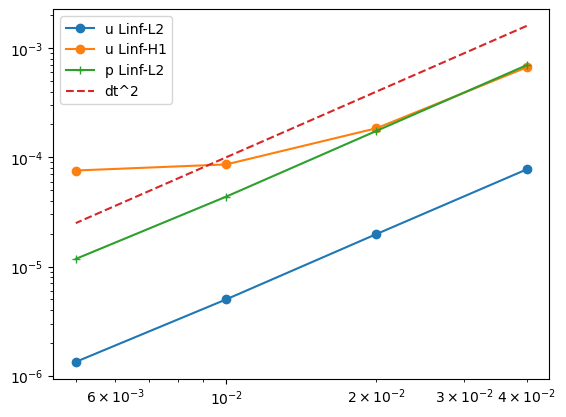

In [36]:
# Convergence analysis.
t0 = 0
T = 0.12
dt_vec = [0.04 * 2**ii for ii in range(0, -4, -1)]
err_u_LinfL2 = [0] * len(dt_vec) # NB the command 0*dt_vec would return a scalar
err_u_LinfH1 = [0] * len(dt_vec)
err_p_LinfL2 = [0] * len(dt_vec)

# Convergence loop.
for ii in range(0, len(dt_vec)):
    dt = dt_vec[ii]
    print('##### dt =', dt, '#####', flush=True)
    u0.interpolate(Constant((0., 0.)))
    u_oldold.interpolate(Constant((0., 0.)))
    wh_Eu, vpb_Eu, nsp_Eu = ex1_assemble_Euler(V, Q, Re, n, dt, t0, u_oldold, u_ex, p_ex, f, create_pc_form=create_pc_form_Euler, get_nsp=True)
    wh, vpb, nsp = ex1_assemble_BDF2(V, Q, Re, n, dt, t0, u0, u_oldold, u_ex, p_ex, f, create_pc_form=create_pc_form_BDF2, get_nsp=True)

    # solve 1 time step with Euler method
    err_u_LinfL2_Eu, err_u_LinfH1_Eu, err_p_LinfL2_Eu = solve_time_dependent(u_ex, p_ex, f, sine_2_t, cosine_2_t, t0, t0+dt, wh_Eu, vpb_Eu, nsp_Eu, params, u0)
    # Now proceed with BDF2 method: same solve_time_dependent function, with additional argument u_oldold at the end
    wh.assign(wh_Eu)
    uh_Eu, _ = wh_Eu.subfunctions
    u0.assign(uh_Eu)
    err_u_LinfL2[ii], err_u_LinfH1[ii], err_p_LinfL2[ii] = solve_time_dependent(u_ex, p_ex, f, sine_2_t, cosine_2_t, t0+dt, T, wh, vpb, nsp, params, u0, u_oldold)
    # err_u_LinfL2[ii] = max(err_u_LinfL2_Eu, err_u_LinfL2[ii])
    # err_u_LinfH1[ii] = max(err_u_LinfH1_Eu, err_u_LinfH1[ii])
    # err_p_LinfL2[ii] = max(err_p_LinfL2_Eu, err_p_LinfL2[ii])

print('Errors:', err_u_LinfL2, err_u_LinfH1, err_p_LinfL2)
plt.loglog(dt_vec, err_u_LinfL2, marker='o', label='u Linf-L2')
plt.loglog(dt_vec, err_u_LinfH1, marker='o', label='u Linf-H1')
plt.loglog(dt_vec, err_p_LinfL2, marker='+', label='p Linf-L2')
plt.loglog(dt_vec, [dt**2 for dt in dt_vec], linestyle='--', label='dt^2')

plt.legend()